In [1]:
# assign directory
import git
from pathlib import Path
import os
ROOT_DIR = Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
os.chdir(os.path.join(ROOT_DIR, 'utilities'))
from transform_audio import *
CWD = os.path.join(ROOT_DIR, 'dataset-preparation', 'audioData', 'respiratory', 'distribution_comparisons')
os.chdir(CWD)

respiratory_dir = os.path.join(ROOT_DIR, 'raw-data', 'respiratory')
transform_dir = os.path.join(respiratory_dir, 'transforms')
metadata_dir = os.path.join(respiratory_dir, 'metadata')

In [2]:
affix = 'fft'
category = 'wheezes'
group_map = pd.read_csv(os.path.join(metadata_dir, 'cycle_metadata.csv')).set_index('cycle name')['wheezes']
group_map.value_counts()

wheezes
0    4284
1    1125
Name: count, dtype: int64

In [3]:
# partition data by group

partitions_dir = os.path.join(CWD, 'partitions', affix, category)
os.makedirs(partitions_dir, exist_ok=True)

zipfiles = {group: zipfile.ZipFile(
                os.path.join(partitions_dir, f'{affix}_{category}_{group}_coefs.npz'), 'w'
            ) for group in group_map.unique()}

coefs_npz_path = os.path.join(transform_dir, affix + '_coefs.npz')
with np.load(coefs_npz_path, allow_pickle=True) as coefs_npz:
    for file in coefs_npz.files:
        cycle_name = file.rsplit('_', 1)[0]
        group = group_map[cycle_name]
        with zipfiles[group].open(file + '.npy', 'w', force_zip64=True) as zipf_entry:
            np.save(zipf_entry, coefs_npz[file])

for zipfile in zipfiles.values():
    zipfile.close()

In [4]:
# compute pooled bands

subsample_every, batch_size = 10, None # tune these parameters
bands = freq_band_groupings(
    coefs_npz_path,
    subsample_every=subsample_every, 
    batch_size=batch_size,
    presplit_depth=1,
    debug=False
)

In [5]:
def compare_groups(group1, group2, visualize=True):
    group1_coef_bands, group2_coef_bands = (
        group_coefs_by_band(
            load_coefs_by_freq(
                os.path.join(partitions_dir, f'{affix}_{category}_{group}_coefs.npz'),
                subsample_every=subsample_every,
                batch_size=batch_size,
                debug=True
            ), bands
        ) for group in [group1, group2]
    )

    statistics = [ks_2samp(group1_coefs, group2_coefs).statistic
                  for group1_coefs, group2_coefs in zip(group1_coef_bands, group2_coef_bands)]
    
    if visualize:
        plt.figure(figsize=(16, 5))
        plt.bar([f'[{band[0]}, {band[1]})' for band in bands], statistics)
        plt.axhline(.05, ls='--', c='r')
        plt.xlabel('Band index range')
        plt.xticks(rotation=45)
        plt.ylabel('KS statistic')
        plt.title(f'{affix.upper()} distribution comparison between '
                  f'"{category}" partitions: {group1} vs. {group2}')
        plt.show()

    return statistics

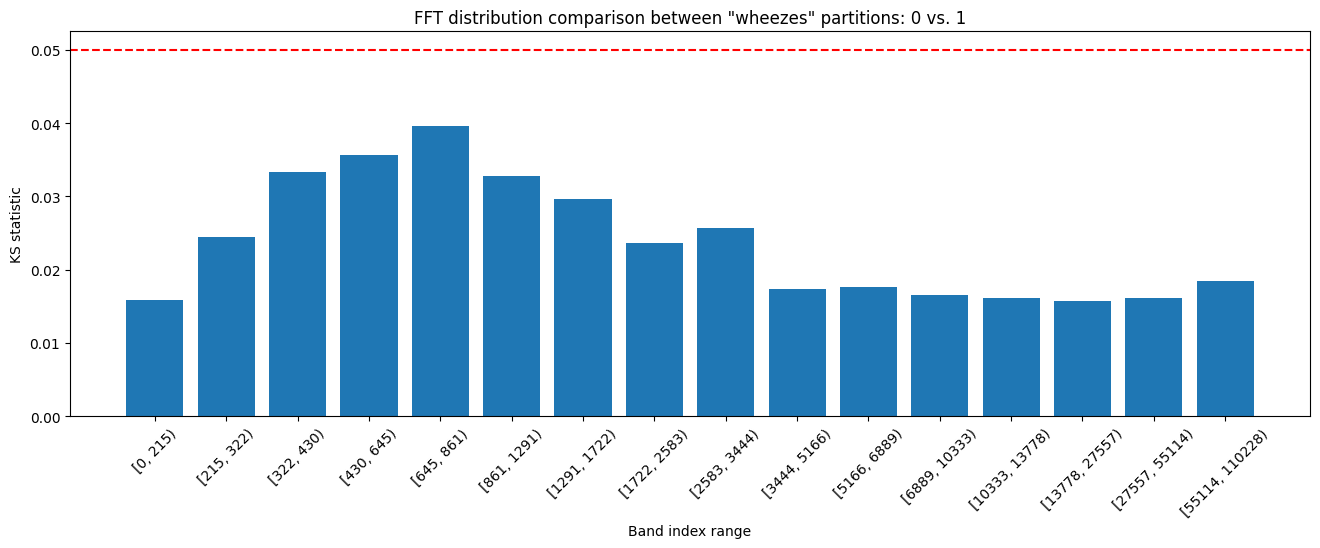

In [6]:
statistics = compare_groups(0, 1, visualize=True)

In [7]:
# optionally delete partition coefficient archives

for file in Path(partitions_dir).iterdir():
    file.unlink()